# 01 · The data: links, radar and PWS on one 5-minute grid

What `run.py build` makes for each network (`multisensor_nowcasting.cube`): the radar, the
link and PWS maps, the sparse sensor channels, and the radar adjusted with links, PWS or
both, every 5 minutes on 2-km pixels. See the project README for the sources and DOIs.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")       # torch + pysteps in one process (macOS)
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "projects" / "multisensor_nowcasting" / "src"))
RES = ROOT / "projects" / "multisensor_nowcasting" / "results"
from multisensor_nowcasting.settings import NETWORKS
from multisensor_nowcasting.cube import Cube
from multisensor_nowcasting.report import label
NETS = [n for n in NETWORKS if Cube.exists(n)]
plt.rcParams.update({"figure.dpi": 72, "axes.titlesize": 10})
pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)
print("networks with a cube:", NETS)

networks with a cube: ['openmrg', 'openmesh']


In [2]:
import json
for net in NETS:
    c = Cube(net)
    print(NETWORKS[net].label)
    print(json.dumps(c.meta, indent=1))
    print("split shares (train, validation, test):", np.round(np.bincount(c.split, minlength=3) / c.split.size, 3), "\n")

Gothenburg (OpenMRG + OpenMRG2), JJA 2015
{
 "network": "openmrg",
 "grid_shape": [
  44,
  35
 ],
 "pixel_km": 2.0,
 "n_steps": 26496,
 "n_links": 358,
 "n_virtual_gauges": 1398,
 "n_pws": 28,
 "n_pws_raw": 30,
 "retrieval": "projects/cml_rnn gru_physics_nbr hourly totals, spread over 5-min steps by the power-law rate of the 1-min excess loss",
 "radar_valid_share": 0.9904815821256039,
 "build_seconds": 68
}
split shares (train, validation, test): [0.377 0.187 0.436] 

New York City (OpenMesh), Nov 2023 - Jun 2024, rain events
{
 "network": "openmesh",
 "grid_shape": [
  120,
  120
 ],
 "pixel_km": 2.0,
 "n_steps": 10115,
 "n_links": 26,
 "n_virtual_gauges": 86,
 "n_pws": 34,
 "n_pws_raw": 37,
 "retrieval": "projects/cml_rnn gru_physics_nbr hourly totals, spread over 5-min steps by the power-law rate of the 1-min excess loss",
 "radar_valid_share": 0.9838757002801121,
 "build_seconds": 819
}
split shares (train, validation, test): [0.404 0.135 0.461] 



## The channels at one stormy step

The wettest test-split step of each network (most radar cells above 1 mm/h).

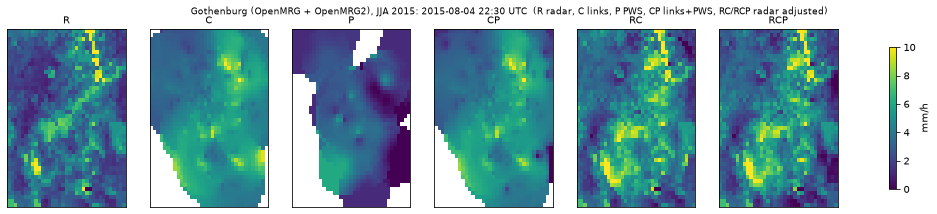

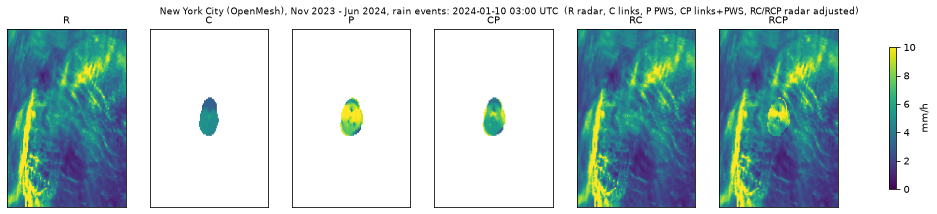

In [3]:
from multisensor_nowcasting.cube import cell_index
for net in NETS:
    c = Cube(net)
    R = c["R"]
    cand = np.flatnonzero(c.split == 2)[::6]
    k = cand[np.argmax([np.nanmean(np.asarray(R[i]) > 1) for i in cand])]
    names = ["R", "C", "P", "CP", "RC", "RCP"]
    fig, axes = plt.subplots(1, len(names), figsize=(3.1 * len(names), 3.2))
    ext = [c.grid.lon[0], c.grid.lon[-1], c.grid.lat[0], c.grid.lat[-1]]
    for ax, ch in zip(axes, names):
        im = ax.imshow(np.ma.masked_invalid(np.asarray(c[ch][k])), origin="lower", extent=ext, aspect="auto",
                       cmap="viridis", vmin=0, vmax=10)
        ax.set_title(ch)
        ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=axes, label="mm/h", shrink=0.8)
    fig.suptitle(f"{NETWORKS[net].label}: {c.times[k]:%Y-%m-%d %H:%M} UTC  "
                 "(R radar, C links, P PWS, CP links+PWS, RC/RCP radar adjusted)", fontsize=9)
    plt.show()

## Each product against the independent gauges, test weeks, hourly

The *mapping* skill before any nowcasting: hourly means of each 5-minute product at the
gauges' cells against the gauges, in the test weeks (Gothenburg: the 10 city gauges;
New York: the four ASOS stations).

In [4]:
from multisensor_nowcasting import scoring
for net in NETS:
    c = Cube(net)
    g = c.gauges["g5"]
    cells = cell_index(c.grid, g.lat.values, g.lon.values)
    test = c.split == 2
    G = g.transpose("time", "station").values[test]
    rows = {}
    for ch in ["R", "C", "P", "CP", "RC", "RP", "RCP"]:
        F = np.asarray(c[ch]).reshape(c.times.size, -1)[test][:, cells]
        t = c.times[test]
        fh = pd.DataFrame(F, index=t).resample("1h", closed="right", label="right").mean().values.ravel()
        oh = pd.DataFrame(G, index=t).resample("1h", closed="right", label="right").mean().values.ravel()
        rows[ch] = scoring.point_scores(fh, oh)
    print(NETWORKS[net].label)
    print(pd.DataFrame(rows).T.round(3), "\n")

Gothenburg (OpenMRG + OpenMRG2), JJA 2015
          n   RMSE   corr   bias
R    9512.0  0.577  0.736 -0.020
C    9542.0  0.419  0.862  0.082
P    9582.0  0.437  0.858 -0.145
CP   9582.0  0.417  0.865  0.067
RC   9512.0  0.409  0.871  0.101
RP   9512.0  0.464  0.827 -0.029
RCP  9512.0  0.400  0.875  0.085 



New York City (OpenMesh), Nov 2023 - Jun 2024, rain events
          n   RMSE   corr   bias
R    1246.0  1.487  0.857 -0.173
C    1213.0  1.726  0.744 -0.123
P    1246.0  1.156  0.922  0.206
CP   1246.0  1.096  0.906  0.060
RC   1246.0  1.584  0.803 -0.108
RP   1246.0  0.969  0.951  0.239
RCP  1246.0  0.858  0.952  0.171 

